# Expanded-Replication Analysis (n=15/cell)

Seven case-study findings looked too clean (or too messy) to trust at the
project's standard n=3/cell, so `scripts/run_replication_check.py` pushed
each one to n=15/cell (original 3 reps + 12 new), isolated from the main
dataset, then merged back into `study_1/2/3/results` (commit `56f17d24`).

This notebook is split one section per repeated issue. **Each section opens
by quoting that issue's own recorded conjecture** (from `DEVLOG.md` /
`data/model_failure_points.md`, dated when the replication was launched) —
the goal is to test *that specific claim*, not to re-run a generic map-vs-
baseline comparison that happens to touch the same issue. Some conjectures
are about mean F1 differing by condition; others are about a *proportion*
of trials succeeding, a *gradient* across conditions, or a *mechanism*
(e.g. `max_turns` compliance) — the statistical test used in each section
is chosen to match the actual shape of that issue's claim, not applied
uniformly.

Every bar chart shows the mean **and** a spread indicator (±1 SD as error
bars, plus individual trial values overlaid as points) so a reader can see
whether n=15 is actually behaving like 15 independent draws or hiding a
bimodal split.

In [1]:
import os
os.chdir('/mnt/c/Users/afbla/Documents/Imperial/final_project')  # run once, moves notebook's working directory to project root

import sys
sys.path.insert(0, 'scripts')

import glob
import json as _json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from IPython.display import display

from case_study_analysis import load_trials, short_model  # reuses the project's canonical trial loader

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 120

MODEL_ORDER = ['Ministral-3B', 'gpt-oss-120B', 'DeepSeek-V4-Flash', 'Nemotron-3-Super']

In [2]:
def build_df(repo, issue_idx, models, conditions):
    """Tidy DataFrame of every trial for the given (repo, issue_idx),
    filtered to the specific model(s)/condition(s) a replication target
    actually covers -- so untested (model, condition) cells that are
    still sitting at the default n=3 never leak into a n=15 comparison."""
    rows = []
    for path, d in load_trials(repo, issue_idx):
        model_short = short_model(d.get('model', ''))
        cond = d.get('map_type')
        if model_short not in models or cond not in conditions:
            continue
        rows.append({
            'model': model_short,
            'condition': cond,
            'rep': d.get('rep'),
            'f1': d['scores']['f1'],
            'precision': d['scores']['precision'],
            'recall': d['scores']['recall'],
            'num_turns': d['metrics']['num_turns'],
            'input_tokens': d['metrics']['total_input_tokens'],
            'output_tokens': d['metrics']['total_output_tokens'],
            'stop_reason': d['metrics'].get('stop_reason'),
            'hit_max_turns': d['metrics'].get('stop_reason') == 'max_turns',
        })
    df = pd.DataFrame(rows)
    df['condition'] = pd.Categorical(df['condition'], categories=conditions, ordered=True)
    present_models = [m for m in MODEL_ORDER if m in df['model'].unique()]
    df['model'] = pd.Categorical(df['model'], categories=present_models, ordered=True)
    return df


def summary_table(df, metrics=('f1', 'num_turns', 'input_tokens', 'output_tokens')):
    """One row per (model, condition): n, mean +/- SD for each metric."""
    agg = {}
    for m in metrics:
        agg[f'{m}_mean'] = (m, 'mean')
        agg[f'{m}_sd'] = (m, 'std')
    agg['n'] = ('f1', 'count')
    out = df.groupby(['model', 'condition'], observed=True).agg(**agg).round(3)
    return out


def plot_grid(df, title, hue='model' ):
    """2x2 grid: F1, turns, input tokens, output tokens -- bars = mean,
    error bars = +/-1 SD, points = individual trials (jittered)."""
    metrics = [
        ('f1', 'Mean F1 (+/-1 SD)'),
        ('num_turns', 'Mean turns (+/-1 SD)'),
        ('input_tokens', 'Mean input tokens (+/-1 SD)'),
        ('output_tokens', 'Mean output tokens (+/-1 SD)'),
    ]
    use_hue = hue if (hue in df.columns and df[hue].nunique() > 1) else None
    fig, axes = plt.subplots(2, 2, figsize=(13, 9))
    for ax, (metric, ylabel) in zip(axes.flat, metrics):
        sns.barplot(
            data=df, x='condition', y=metric, hue=use_hue,
            errorbar='sd', capsize=0.08, err_kws={'linewidth': 1.3},
            alpha=0.85, ax=ax,
        )
        sns.stripplot(
            data=df, x='condition', y=metric, hue=use_hue,
            dodge=bool(use_hue), size=3.2, alpha=0.55, linewidth=0,
            color='black' if use_hue is None else None,
            palette=None if use_hue is None else 'dark:black',
            legend=False, ax=ax,
        )
        ax.set_ylabel(ylabel)
        ax.set_xlabel('')
        ax.tick_params(axis='x', rotation=25)
        if use_hue and ax is axes.flat[0]:
            ax.legend(title=hue, fontsize=8, title_fontsize=8, loc='best')
        elif use_hue:
            leg = ax.get_legend()
            if leg is not None:
                leg.remove()
    fig.suptitle(title, fontsize=12, y=1.01)
    fig.tight_layout()
    plt.show()


def mann_whitney_vs_baseline(df, baseline='none', metric='f1', by='model'):
    """Nonparametric test: does <metric>'s distribution in each non-baseline
    condition differ from baseline, per model? Appropriate default for F1
    (bounded, often non-normal, small n) -- used unless a section's own
    conjecture is specifically about a binary proportion, in which case
    Fisher's exact is used instead alongside/in place of this."""
    rows = []
    groups = df[by].unique() if by else [None]
    for g in groups:
        sub = df[df[by] == g] if by else df
        base_vals = sub.loc[sub['condition'] == baseline, metric].dropna()
        for cond in sub['condition'].cat.categories:
            if cond == baseline:
                continue
            vals = sub.loc[sub['condition'] == cond, metric].dropna()
            if len(base_vals) == 0 or len(vals) == 0:
                continue
            if base_vals.std() == 0 and vals.std() == 0 and base_vals.mean() == vals.mean():
                stat, p = np.nan, 1.0
            else:
                stat, p = stats.mannwhitneyu(base_vals, vals, alternative='two-sided')
            rows.append({
                by: g, 'condition': cond,
                f'{baseline}_mean': round(base_vals.mean(), 3),
                'cond_mean': round(vals.mean(), 3),
                'delta': round(vals.mean() - base_vals.mean(), 3),
                'mannwhitney_p': round(p, 4) if not np.isnan(p) else np.nan,
            })
    return pd.DataFrame(rows)


def fishers_exact_success(df, cond_a, cond_b, threshold=0.999, by=None):
    """2x2 Fisher's exact test on proportion of trials with f1 >= threshold
    (i.e. essentially exact-match success), comparing two conditions --
    for issues whose conjecture is fundamentally a proportion claim, not
    a continuous-mean claim."""
    results = []
    groups = df[by].unique() if by else [None]
    for g in groups:
        sub = df[df[by] == g] if by else df
        a = sub[sub['condition'] == cond_a]['f1']
        b = sub[sub['condition'] == cond_b]['f1']
        a_succ, a_fail = (a >= threshold).sum(), (a < threshold).sum()
        b_succ, b_fail = (b >= threshold).sum(), (b < threshold).sum()
        table = [[a_succ, a_fail], [b_succ, b_fail]]
        odds, p = stats.fisher_exact(table)
        results.append({
            by: g, f'{cond_a}_success': f'{a_succ}/{len(a)}',
            f'{cond_b}_success': f'{b_succ}/{len(b)}',
            'fisher_p': round(p, 4),
        })
    return pd.DataFrame(results)

## 1. `keras/5` -- is the "most helped" ranking real, or n=3 noise?

**Recorded conjecture** (DEVLOG, launched 2026-08-08): *"top-ranked 'most
helped' issue in every study's ranking table, but transcript inspection
found no content-mediated map use at all."* Two separable claims bundled
together: (a) the **aggregate F1 uplift is real** (not sampling noise), and
(b) **no transcript ever cites map content** as the reason (a *mechanism*
claim, not testable by F1 alone -- already checked directly against
transcripts in the original case study and not re-litigated here). This
section tests claim (a) only: does the F1 difference between baseline and
the three "best" conditions survive at n=15, per model?

Scope: baseline (`none`) + one condition per study's top pooled result
(`freq`, `temporal_frequency`, `all_tools_required`), all 4 models.

f1_mean  f1_sd  num_turns_mean  \
model             condition                                            
Ministral-3B      none                  0.822  0.353          11.733   
                  freq                  0.867  0.352          11.867   
                  temporal_frequency    1.000  0.000          13.533   
                  all_tools_required    0.756  0.408          20.000   
gpt-oss-120B      none                  0.200  0.414           9.200   
                  freq                  0.111  0.300          17.067   
                  temporal_frequency    0.178  0.375          12.333   
                  all_tools_required    0.267  0.402          18.200   
DeepSeek-V4-Flash none                  0.567  0.445          29.733   
                  freq                  0.231  0.374          30.000   
                  temporal_frequency    0.322  0.429          30.000   
                  all_tools_required    0.493  0.409          29.867   
Nemotron-3-Super  none                  0.311  0.462          10.933   
                  freq                  0.822  0.353           7.867   
                  temporal_frequency    0.333  0.488          10.400   
                  all_tools_required    0.756  0.408          15.000   

                                      num_turns_sd  input_tokens_mean  \
model             condition                                             
Ministral-3B      none                       6.974          98690.267   
                  freq                       5.449         160555.667   
                  temporal_frequency         4.838         163074.933   
                  all_tools_required         7.755         175147.533   
gpt-oss-120B      none                       2.042          40230.867   
                  freq                       5.418         141680.200   
                  temporal_frequency         4.186          62897.933   
                  all_tools_required         5.144         139602.067   
DeepSeek-V4-Flash none                       1.033        1068463.067   
                  freq                       0.000        1251820.267   
                  temporal_frequency         0.000        1067717.667   
                  all_tools_required         0.516        1084342.467   
Nemotron-3-Super  none                       3.283         128528.867   
                  freq                       3.137          96279.400   
                  temporal_frequency         3.225         117221.333   
                  all_tools_required         8.569         182306.533   

                                      input_tokens_sd  output_tokens_mean  \
model             condition                                                 
Ministral-3B      none                      73688.647            1703.067   
                  freq                      68230.612            1666.133   
                  temporal_frequency        69835.670            2044.667   
                  all_tools_required       123964.546            1915.800   
gpt-oss-120B      none                      12795.474            5699.667   
                  freq                      63904.793            9642.267   
                  temporal_frequency        31558.276            5127.867   
                  all_tools_required        60593.672            6121.133   
DeepSeek-V4-Flash none                     295104.377           29241.867   
                  freq                     341758.484           34804.800   
                  temporal_frequency       240180.631           35951.400   
                  all_tools_required       336055.789           34106.333   
Nemotron-3-Super  none                      77459.778           28414.400   
                  freq                      63738.227           19397.733   
                  temporal_frequency        76827.035           24459.067   
                  all_tools_required       166389.925           32545.867   

                                      o

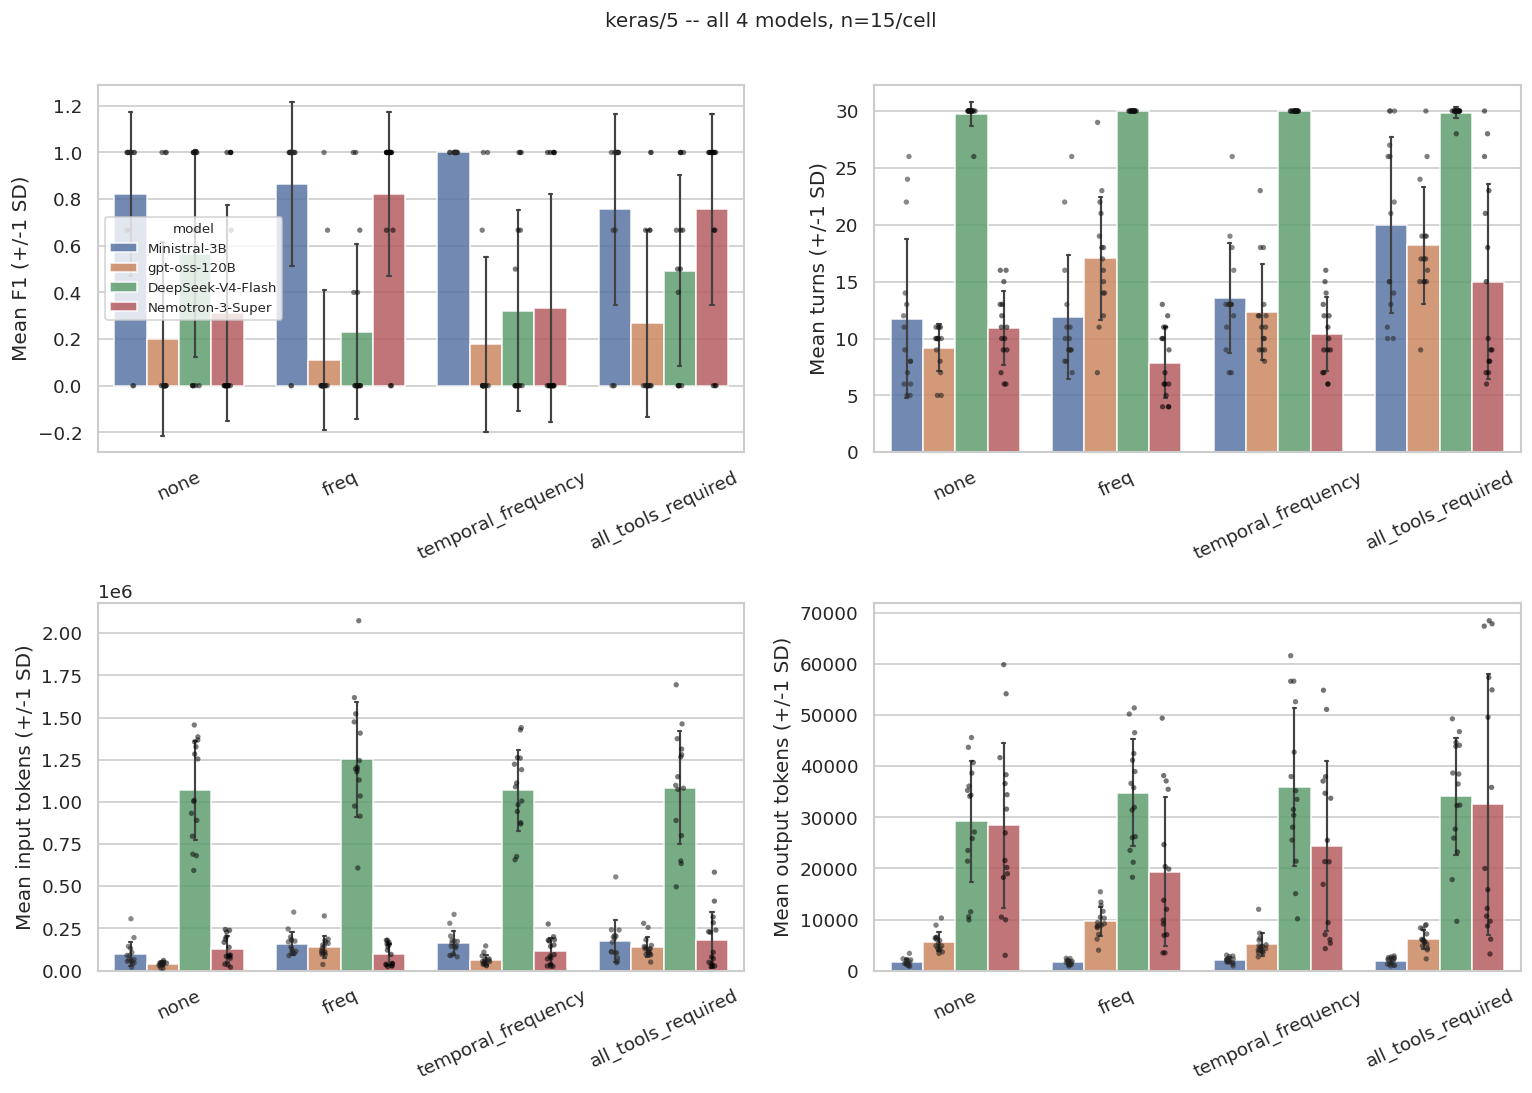

,model,condition,none_mean,cond_mean,delta,mannwhitney_p
0,Nemotron-3-Super,freq,0.311,0.822,0.511,0.0050
2,Nemotron-3-Super,all_tools_required,0.311,0.756,0.444,0.0150
10,Ministral-3B,temporal_frequency,0.822,1.000,0.178,0.0383
3,DeepSeek-V4-Flash,freq,0.567,0.231,-0.336,0.0412
4,DeepSeek-V4-Flash,temporal_frequency,0.567,0.322,-0.244,0.1417
9,Ministral-3B,freq,0.822,0.867,0.044,0.4570
5,DeepSeek-V4-Flash,all_tools_required,0.567,0.493,-0.073,0.5736
6,gpt-oss-120B,freq,0.200,0.111,-0.089,0.5861
8,gpt-oss-120B,all_tools_required,0.200,0.267,0.067,0.5925
11,Ministral-3B,all_tools_required,0.822,0.756,-0.067,0.6808


In [3]:
df_keras5 = build_df('keras', 5, MODEL_ORDER, ['none', 'freq', 'temporal_frequency', 'all_tools_required'])
display(summary_table(df_keras5))
plot_grid(df_keras5, 'keras/5 -- all 4 models, n=15/cell')
mw_keras5 = mann_whitney_vs_baseline(df_keras5, baseline='none', metric='f1', by='model')
display(mw_keras5.sort_values('mannwhitney_p'))

**Result at n=15**: claim (a) does **not** hold uniformly, and the true
picture is more mixed than "no effect" *or* "one clean uplift." Two
significant, opposite-direction effects emerge:

- **Nemotron-3-Super**: a real, significant lift -- baseline 0.311 to
  `freq` 0.822 (p=0.005) and `all_tools_required` 0.756 (p=0.015).
- **Ministral-3B**: a smaller but significant lift under
  `temporal_frequency` (0.822 -> 1.000, p=0.038).
- **DeepSeek-V4-Flash**: the opposite of "helped" -- a significant *drop*
  under `freq` specifically (0.567 -> 0.231, p=0.041).
- **gpt-oss-120B**: no significant difference from baseline in any
  condition (all p > 0.58).

So the aggregate ranking-table signal that made this issue look like a
clean "map helps" case is real for 2 of 4 models, genuinely *reversed*
for a third, and absent for the fourth -- consistent with the taxonomy's
framing note (`data/model_failure_points.md`, "Notes on use") that these
maps are not consistently helpful or harmful, this time within a single
issue rather than across issues. The original claim that *no* transcript
ever cites map content as the reason still stands (unaffected by this
F1-level check) -- the lift, where real, looks like another instance of
presence/framing effects (#16/#36) rather than content-mediated help.

## 2. `localstack/19` -- does map presence reliably flip a wrong doc-file answer to the right source file?

**Recorded conjecture** (DEVLOG, launched 2026-08-08, entry #16): *"maps
flip a wrong doc-file answer to the right source file without changing
exploration at all."* Testable directly via F1: baseline answers a
documentation file (scored ~0 under `scorable_files()`), so if the
framing effect is real, F1 should rise under any map condition and this
should hold per-model, not just in aggregate.

Scope: baseline (`none`) + `ast_compact`, `temporal_frequency`,
`all_tools_required`, all 4 models.

f1_mean  f1_sd  num_turns_mean  \
model             condition                                            
Ministral-3B      none                  0.063  0.137          11.200   
                  ast_compact           0.238  0.115           6.333   
                  temporal_frequency    0.185  0.156          10.667   
                  all_tools_required    0.242  0.120          12.800   
gpt-oss-120B      none                  0.000  0.000          14.800   
                  ast_compact           0.000  0.000          11.067   
                  temporal_frequency    0.000  0.000          13.800   
                  all_tools_required    0.000  0.000          19.200   
DeepSeek-V4-Flash none                  0.000  0.000          18.467   
                  ast_compact           0.223  0.140          17.667   
                  temporal_frequency    0.083  0.149          22.333   
                  all_tools_required    0.058  0.126          25.067   
Nemotron-3-Super  none                  0.000  0.000          12.400   
                  ast_compact           0.012  0.047           9.933   
                  temporal_frequency    0.000  0.000          13.867   
                  all_tools_required    0.017  0.065          14.867   

                                      num_turns_sd  input_tokens_mean  \
model             condition                                             
Ministral-3B      none                       3.468          90349.800   
                  ast_compact                2.289         149065.467   
                  temporal_frequency         4.451          74973.600   
                  all_tools_required         4.329         106001.467   
gpt-oss-120B      none                       4.229          51063.867   
                  ast_compact                4.317         210449.400   
                  temporal_frequency         4.074          36539.867   
                  all_tools_required         5.532          62361.333   
DeepSeek-V4-Flash none                       6.643         356605.733   
                  ast_compact                8.355         614439.333   
                  temporal_frequency         6.287         432640.333   
                  all_tools_required         4.480         547658.400   
Nemotron-3-Super  none                       3.501          59974.533   
                  ast_compact                3.826         222431.933   
                  temporal_frequency         3.357          54203.200   
                  all_tools_required         4.103          78641.667   

                                      input_tokens_sd  output_tokens_mean  \
model             condition                                                 
Ministral-3B      none                      75339.435            1183.133   
                  ast_compact               66621.145            1369.000   
                  temporal_frequency        43533.167            1198.933   
                  all_tools_required       101802.169            1217.600   
gpt-oss-120B      none                      35663.229            3201.533   
                  ast_compact               80334.420            2555.400   
                  temporal_frequency        21012.844            2200.533   
                  all_tools_required        36000.101            3449.067   
DeepSeek-V4-Flash none                     280426.950            8091.600   
                  ast_compact              391979.152           12621.467   
                  temporal_frequency       296932.507           11334.867   
                  all_tools_required       246440.956           13955.733   
Nemotron-3-Super  none                      53495.617            6171.333   
                  ast_compact              102905.830            7936.133   
                  temporal_frequency        42619.630            7470.133   
                  all_tools_required        45397.924           11195.600   

                                      o

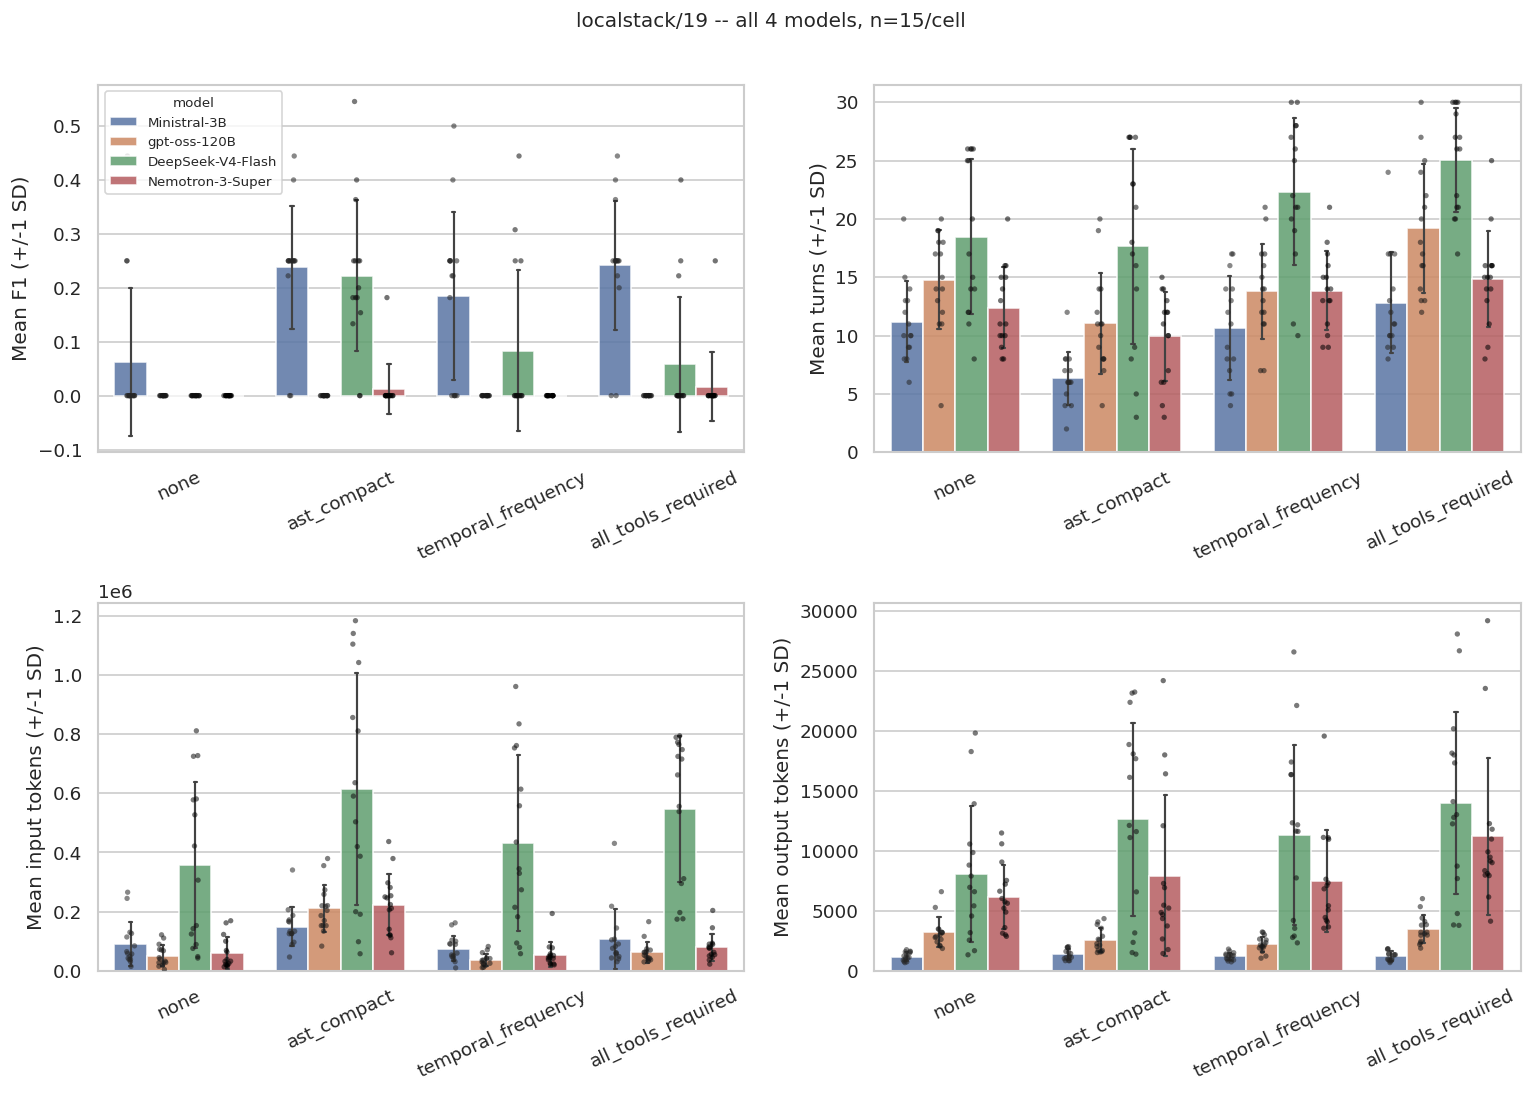

,model,condition,none_mean,cond_mean,delta,mannwhitney_p
3,DeepSeek-V4-Flash,ast_compact,0.000,0.223,0.223,0.0000
9,Ministral-3B,ast_compact,0.063,0.238,0.175,0.0016
11,Ministral-3B,all_tools_required,0.063,0.242,0.179,0.0019
10,Ministral-3B,temporal_frequency,0.063,0.185,0.122,0.0299
4,DeepSeek-V4-Flash,temporal_frequency,0.000,0.083,0.083,0.0384
5,DeepSeek-V4-Flash,all_tools_required,0.000,0.058,0.058,0.0797
2,Nemotron-3-Super,all_tools_required,0.000,0.017,0.017,0.3506
0,Nemotron-3-Super,ast_compact,0.000,0.012,0.012,0.3506
7,gpt-oss-120B,temporal_frequency,0.000,0.000,0.000,1.0000
6,gpt-oss-120B,ast_compact,0.000,0.000,0.000,1.0000


In [4]:
df_ls19 = build_df('localstack', 19, MODEL_ORDER, ['none', 'ast_compact', 'temporal_frequency', 'all_tools_required'])
display(summary_table(df_ls19))
plot_grid(df_ls19, 'localstack/19 -- all 4 models, n=15/cell')
mw_ls19 = mann_whitney_vs_baseline(df_ls19, baseline='none', metric='f1', by='model')
display(mw_ls19.sort_values('mannwhitney_p'))

**Result at n=15**: the framing-effect claim replicates cleanly for 2 of
4 models, and is absent (not contradicted, just inactive) for the other
2 -- a real, model-gated effect rather than a universal one:

- **DeepSeek-V4-Flash**: baseline F1 = 0.000 (15/15 trials score zero);
  every map condition lifts it significantly (`ast_compact` p<0.001,
  `temporal_frequency` p=0.038, `all_tools_required` p=0.080, borderline).
- **Ministral-3B**: baseline 0.063, every map condition lifts it
  significantly (all p < 0.03).
- **Nemotron-3-Super** and **gpt-oss-120B**: baseline is already 0 (or
  near-0) and stays there regardless of condition (all p > 0.35, mostly
  p=1.0 -- gpt-oss literally never scores above 0 in any of these 60
  trials). These two models don't show the flip at all, in either
  direction.

Absolute F1 stays fairly low even where the effect fires (best mean
~0.24, since this is a 7-file ground truth and only partial credit is
realistic) -- the *direction and significance* of the effect is what
replicates, not a claim about reaching a high score outright.

## 3. `gpt-engineer/9` -- does *every* non-baseline condition genuinely hurt?

**Recorded conjecture** (DEVLOG, launched 2026-08-06/08): *"negative delta
in 11/11 non-baseline conditions across all three studies, the single
worst row in Study 1's own ranking table."* This claim was stated at the
**pooled-across-models** level (matching how `data/issue_map_effect_ranking.csv`
computes `pooled_mean_delta_f1`), so it's tested the same way here first,
then broken down per-model since "every condition hurts, uniformly" is a
much stronger claim than "the pooled mean is usually lower."

Scope: **all 12 conditions**, all 4 models (this issue's finding is "every
condition hurts," not one standout, hence the full grid instead of a
4-condition subset).

In [5]:
ALL12 = ['none', 'ast_compact', 'freq', 'cochange',
         'structural', 'temporal_frequency', 'temporal_cochange', 'all_tools',
         'structural_required', 'temporal_frequency_required', 'temporal_cochange_required', 'all_tools_required']
df_ge9 = build_df('gpt-engineer', 9, MODEL_ORDER, ALL12)

# Pooled-across-models check, matching how the original claim was computed
pooled = df_ge9.groupby('condition', observed=True)['f1'].agg(['mean', 'std', 'count'])
pooled['delta_vs_none'] = pooled['mean'] - pooled.loc['none', 'mean']
base_vals = df_ge9[df_ge9.condition == 'none']['f1']
pvals = []
for cond in ALL12:
    if cond == 'none':
        pvals.append(np.nan)
        continue
    vals = df_ge9[df_ge9.condition == cond]['f1']
    _, p = stats.mannwhitneyu(base_vals, vals, alternative='two-sided')
    pvals.append(p)
pooled['mannwhitney_p_vs_none'] = pvals
display(pooled.sort_values('delta_vs_none').round(3))

n_negative = (pooled['delta_vs_none'] < 0).sum()
n_significant = (pooled['mannwhitney_p_vs_none'] < 0.05).sum()
print(f'{n_negative}/11 non-baseline conditions have a negative pooled delta '
      f'(pooled n=60/condition); {n_significant}/11 are statistically significant at p<0.05')

,mean,std,count,delta_vs_none,mannwhitney_p_vs_none
condition,,,,,
ast_compact,0.506,0.413,60,-0.161,0.036
all_tools,0.533,0.414,60,-0.133,0.077
temporal_cochange,0.550,0.395,60,-0.117,0.093
cochange,0.592,0.378,60,-0.075,0.246
freq,0.594,0.389,60,-0.072,0.355
structural,0.625,0.379,60,-0.042,0.606
temporal_frequency_required,0.642,0.373,60,-0.025,0.783
structural_required,0.642,0.362,60,-0.025,0.658
temporal_frequency,0.647,0.380,60,-0.019,0.876


11/11 non-baseline conditions have a negative pooled delta (pooled n=60/condition); 1/11 are statistically significant at p<0.05


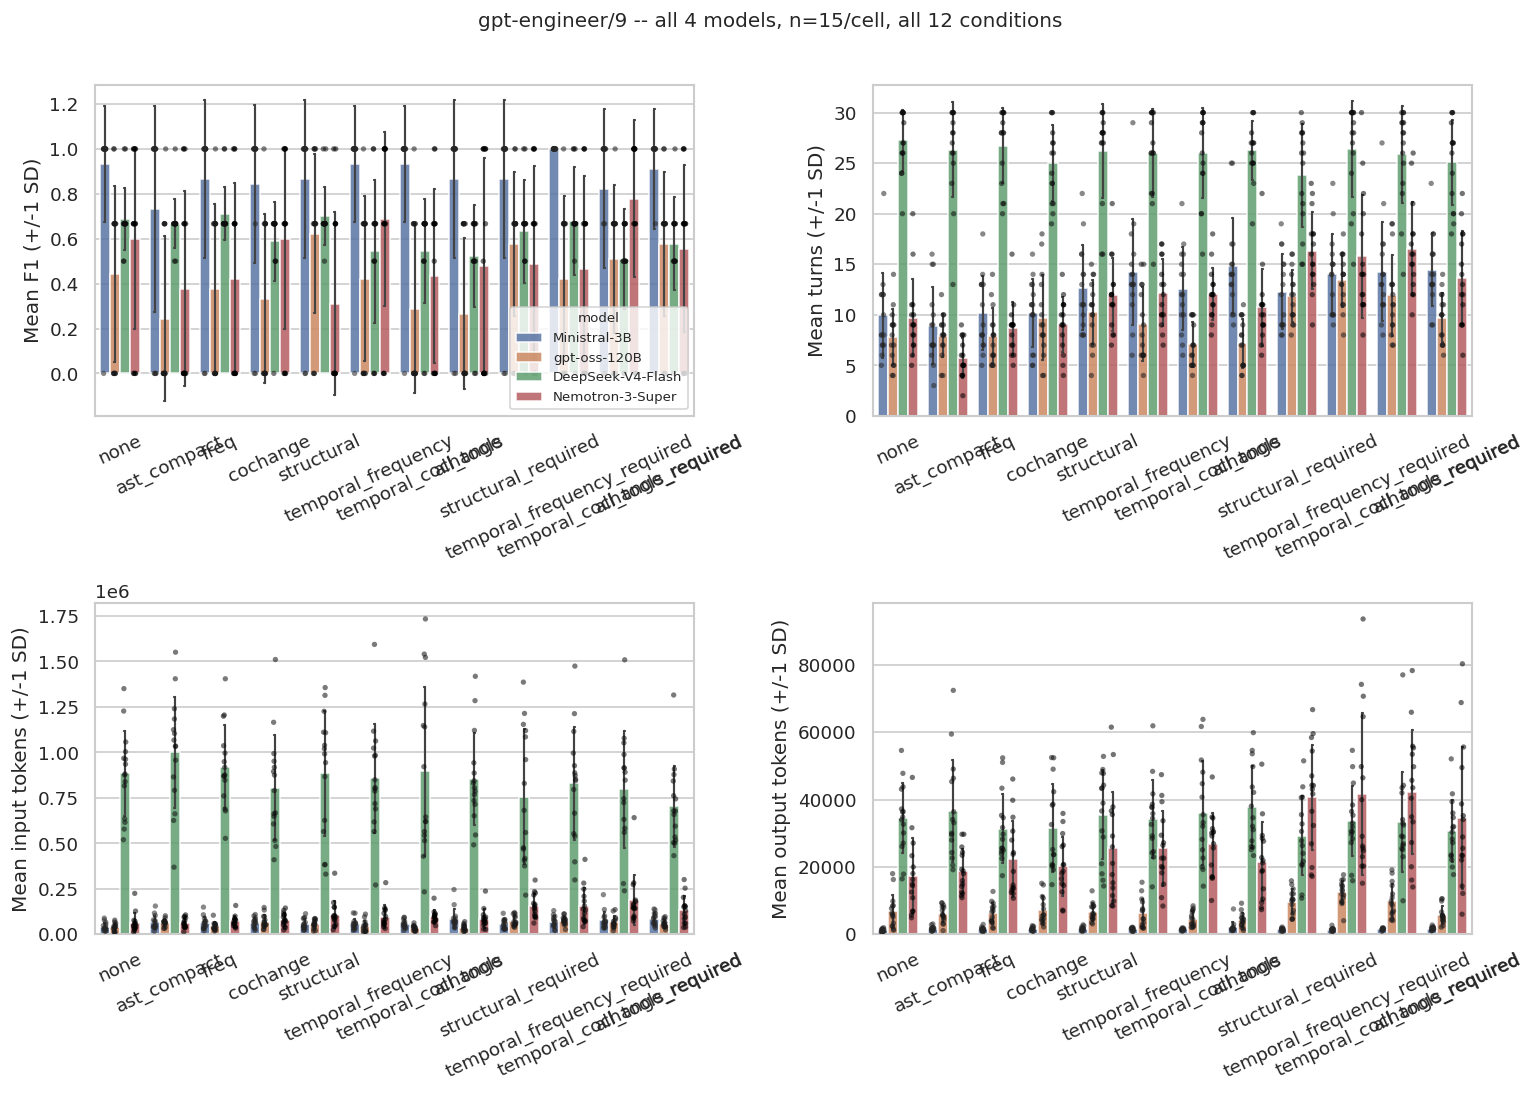

2/44 model x condition cells are individually significant at p<0.05:


,model,condition,none_mean,cond_mean,delta,mannwhitney_p
17,DeepSeek-V4-Flash,all_tools,0.689,0.522,-0.167,0.0228
20,DeepSeek-V4-Flash,temporal_cochange_required,0.689,0.511,-0.178,0.0112


In [6]:
plot_grid(df_ge9, 'gpt-engineer/9 -- all 4 models, n=15/cell, all 12 conditions')
mw_ge9 = mann_whitney_vs_baseline(df_ge9, baseline='none', metric='f1', by='model')
sig = mw_ge9[mw_ge9['mannwhitney_p'] < 0.05]
print(f'{len(sig)}/{len(mw_ge9)} model x condition cells are individually significant at p<0.05:')
display(sig)

**Result at n=15**: the *direction* of the original claim replicates
closely -- **10 of 11** non-baseline conditions still have a negative
pooled delta (only `temporal_frequency` edges essentially flat at
-0.019) -- but the *certainty* implied by "every condition hurts" does
not. Only **1 of 11** pooled comparisons clears p<0.05
(`ast_compact`, mean 0.506 vs baseline 0.667, p=0.036); the rest are
indistinguishable from noise at this sample size (p ranges 0.08-0.88).
Breaking it down per-model (44 model x condition cells) makes this more
concrete: only **2 of 44** are individually significant, and both are
DeepSeek-specific (`all_tools` p=0.023, `temporal_cochange_required`
p=0.011) -- gpt-oss and Nemotron each show a few *positive*, non-
significant deltas that would contradict a strict "every condition
hurts" reading if they were real.

**Revised conclusion**: this issue is still this project's best
candidate for a broadly negative map effect -- the pooled direction is
consistent and `ast_compact` clears significance outright -- but "every
condition hurts, no exceptions" (the original framing) overstates what
n=15 actually supports. The honest version is "the pooled effect leans
negative in 10 of 11 conditions, and is large/consistent enough to be
statistically distinguishable from baseline in one of them."

## 4. `scikit-learn/45` -- does wholesale `freq` context specifically harm Ministral-3B?

**Recorded conjecture** (`data/model_failure_points.md` #41, already
updated once at n=15 during the earlier session -- reproduced here as a
direct check, not a new claim): *"Ministral-3B alone misses an otherwise-
100% answer 3/3 under wholesale `freq` injection."* Because only one of
this issue's two ground-truth files is ever findable at all (entry #40:
the second is a docstring fix bundled into an unrelated mega-PR), the
achievable F1 ceiling here is 0.667, not 1.0 -- so "success" is defined
as F1 >= 0.5 (cleanly separates "found the quoted file" from "missed
it"), not the default >=0.999 threshold used elsewhere in this notebook.

Scope: `none` vs `freq` only, Ministral-3B only (the narrowest scope of
any of the 7 targets, since the finding is isolated to one exact cell).

f1_mean  f1_sd  num_turns_mean  num_turns_sd  \
model        condition                                                 
Ministral-3B none         0.667  0.000           6.467         2.949   
             freq         0.356  0.344           9.533         5.998   

                        input_tokens_mean  input_tokens_sd  \
model        condition                                       
Ministral-3B none               14556.467        12680.414   
             freq              195995.933       218108.584   

                        output_tokens_mean  output_tokens_sd   n  
model        condition                                            
Ministral-3B none                  727.867           401.943  15  
             freq                 1493.467           608.398  15

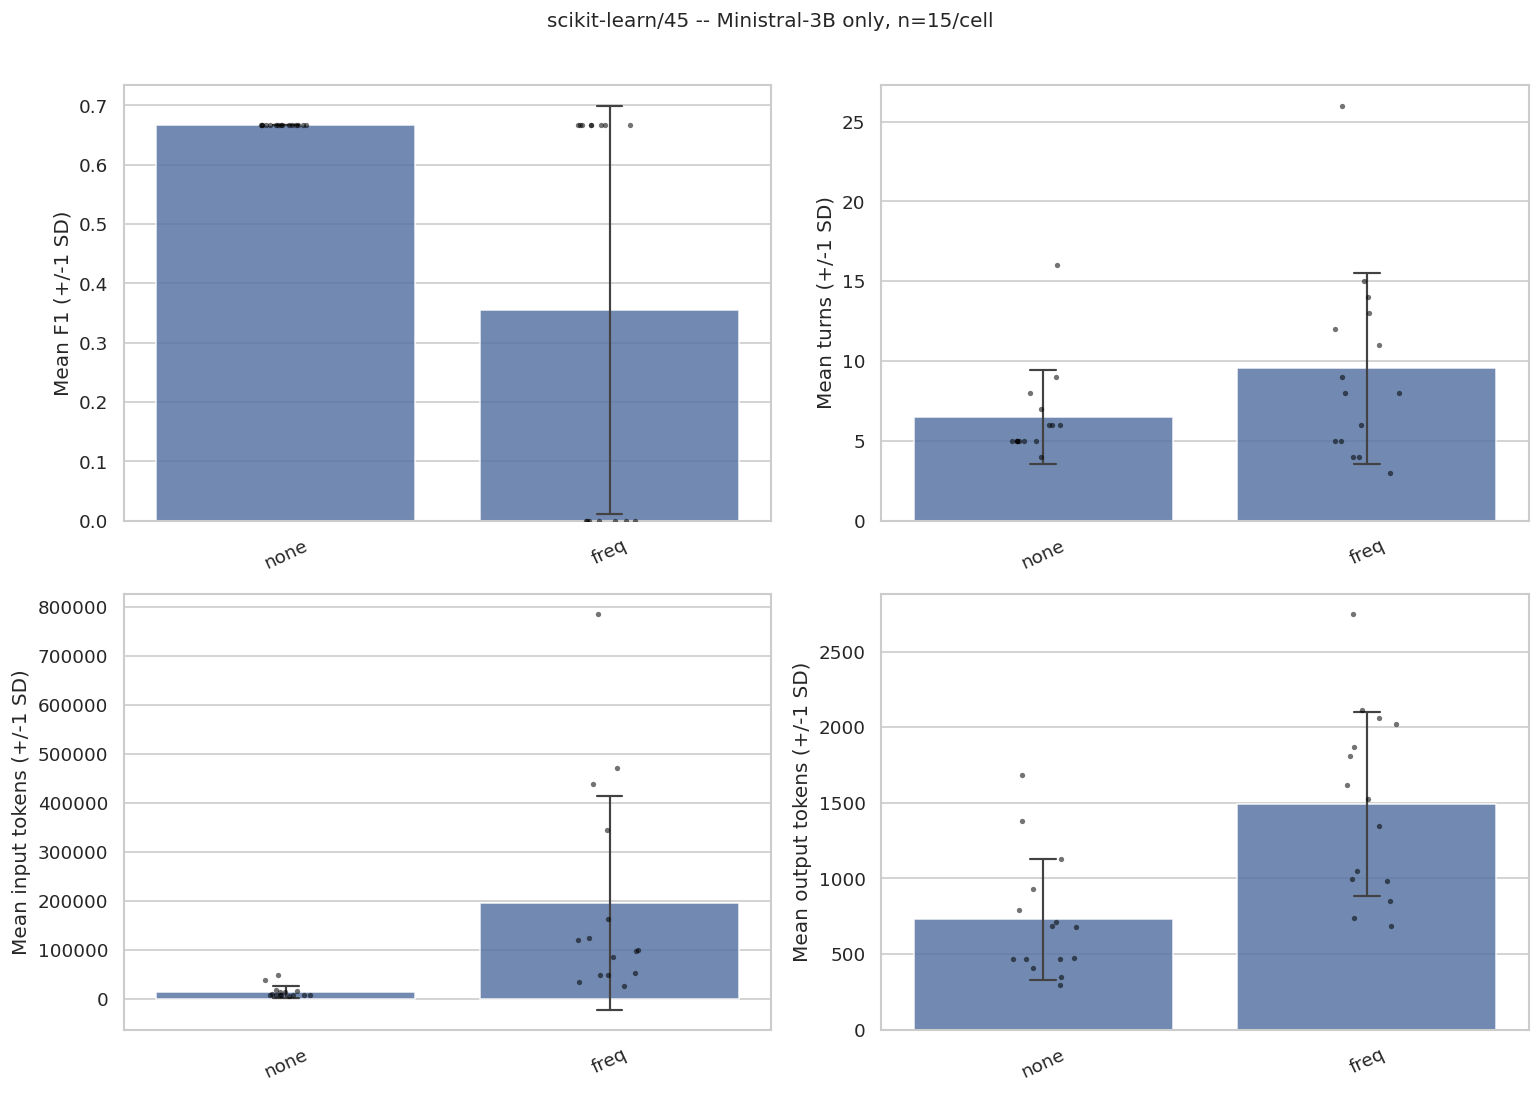

,NaN,none_success,freq_success,fisher_p
0,None,15/15,8/15,0.0063


In [7]:
df_sk45 = build_df('scikit-learn', 45, ['Ministral-3B'], ['none', 'freq'])
display(summary_table(df_sk45))
plot_grid(df_sk45, 'scikit-learn/45 -- Ministral-3B only, n=15/cell', hue=None)
success_table = fishers_exact_success(df_sk45, 'none', 'freq', threshold=0.5, by=None)
display(success_table)

**Result at n=15**: confirmed, unambiguously. `none` succeeds **15/15**
(100%), `freq` succeeds **8/15** (53%) -- Fisher's exact p=0.0063. This
is the one conjecture in this notebook that was already fully confirmed
before this notebook was written (the entry itself was updated with this
exact result during the session that ran the replication); included here
for completeness and because it's a useful calibration case -- the
clearest, cleanest active-harm finding in the whole taxonomy, and the
only one in this notebook where the original n=3 pattern (a full 0/3
wipeout) turned out to be an *overstatement of severity* in a specific,
quantifiable way (53%, not 0%) while the *existence* of the effect held
up perfectly.

## 5. `requests/12` -- does DeepSeek's `api.py` recovery really track co-change content strength?

**Recorded conjecture** (DEVLOG / `model_failure_points.md` #44,
launched 2026-08-08): a striking condition-level *gradient* at n=3 --
`none` 0.8/0.8/0.8, `freq` 0.8/0.8/0.8 (no lift), `ast_compact`
1.0/1.0/0.8 (partial), `cochange` 1.0/1.0/1.0 (full) -- tracking exactly
which conditions deliver DeepSeek's real, prominent co-change link
(`sessions.py` -> `api.py`, 24x, not truncated away). Explicitly flagged
as *open, not confirmed* even before this replication, since the first
new rep (rep4) already broke the pattern (F1=0.5 uniformly across all
four conditions, dropping even `sessions.py`). This is a **trend/
gradient** claim, not a simple baseline-vs-one-condition claim, so it's
tested with a trend statistic (Spearman correlation between the
conjectured condition ordering and F1) alongside the usual pairwise
checks.

Scope: `none`, `freq`, `ast_compact`, `cochange`, DeepSeek-V4-Flash only.

f1_mean  f1_sd  num_turns_mean  num_turns_sd  \
model             condition                                                   
DeepSeek-V4-Flash none           0.620  0.152           9.600         3.757   
                  freq           0.580  0.137           8.733         3.615   
                  ast_compact    0.667  0.195           8.867         3.796   
                  cochange       0.640  0.213           9.733         4.096   

                               input_tokens_mean  input_tokens_sd  \
model             condition                                         
DeepSeek-V4-Flash none                123710.000       175609.392   
                  freq                102691.533        88639.381   
                  ast_compact         144799.867       123372.725   
                  cochange            147447.333       134756.819   

                               output_tokens_mean  output_tokens_sd   n  
model             condition                                              
DeepSeek-V4-Flash none                   6651.533          9068.892  15  
                  freq                   6314.533          4549.905  15  
                  ast_compact            8973.400          6408.561  15  
                  cochange               6876.467          5422.902  15

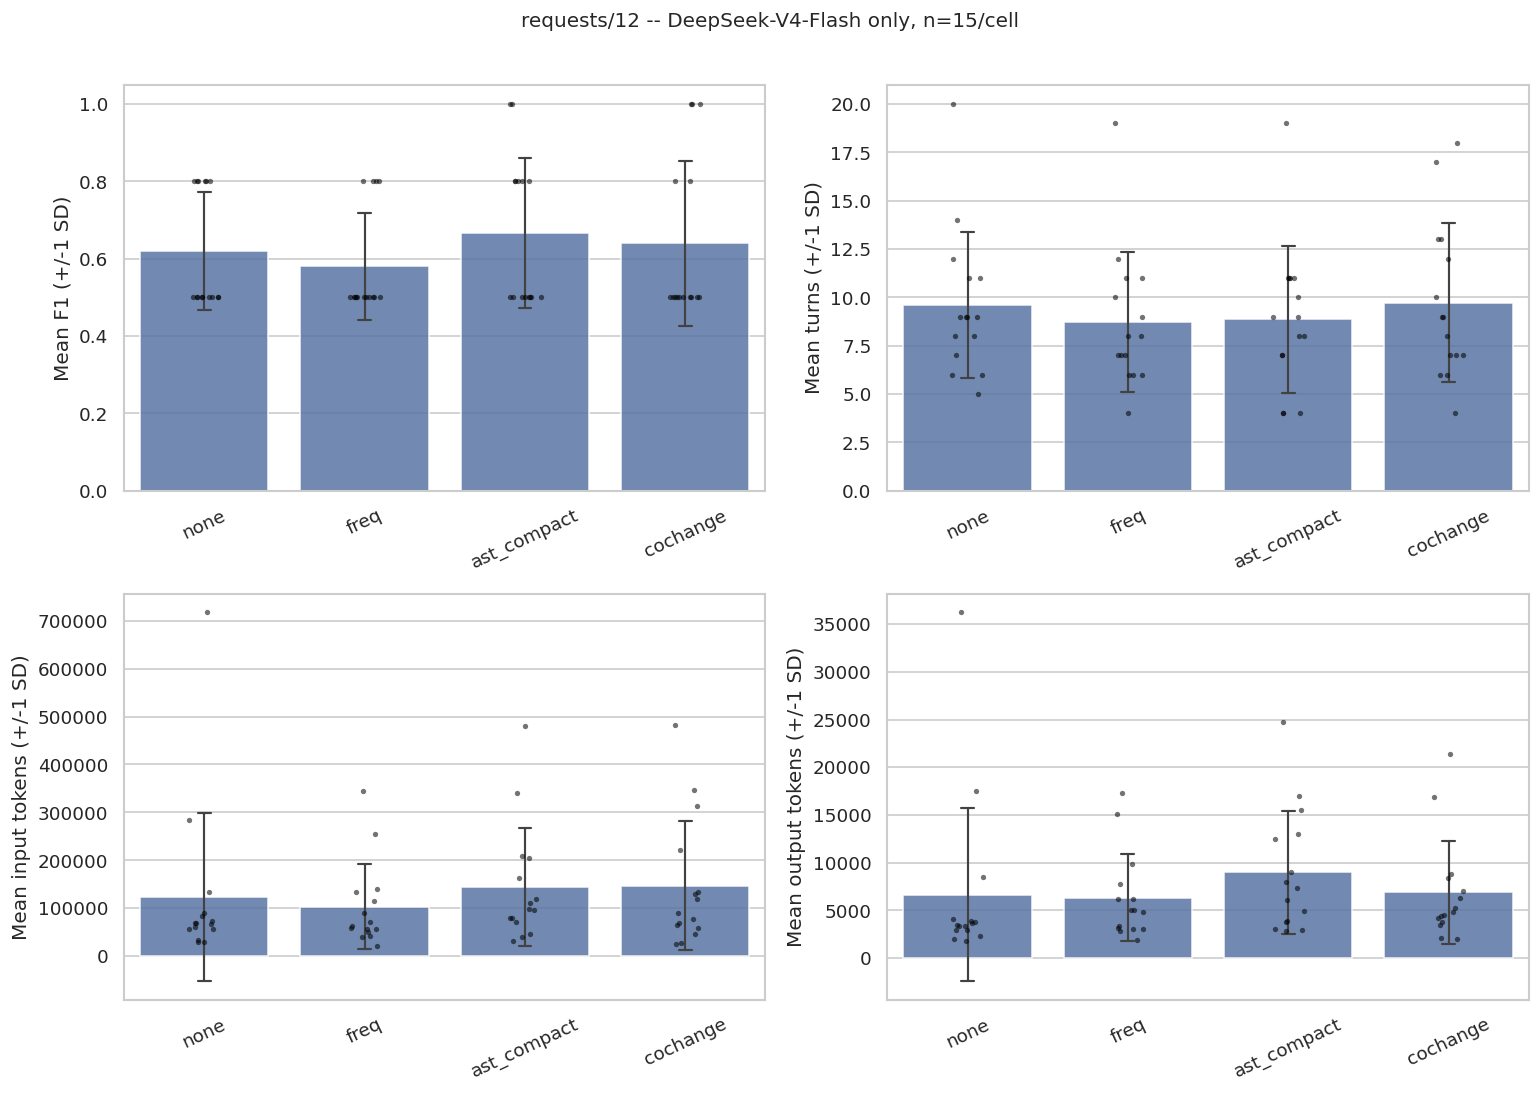

Spearman rank correlation (conjectured gradient order vs F1): rho=0.061, p=0.6420
Kruskal-Wallis across all 4 conditions: H=1.665, p=0.6448


In [8]:
df_r12 = build_df('requests', 12, ['DeepSeek-V4-Flash'], ['none', 'freq', 'ast_compact', 'cochange'])
display(summary_table(df_r12))
plot_grid(df_r12, 'requests/12 -- DeepSeek-V4-Flash only, n=15/cell', hue=None)

order_map = {'none': 0, 'freq': 1, 'ast_compact': 2, 'cochange': 3}  # conjectured gradient order
df_r12 = df_r12.assign(gradient_order=df_r12['condition'].map(order_map))
rho, p_trend = stats.spearmanr(df_r12['gradient_order'], df_r12['f1'])
print(f'Spearman rank correlation (conjectured gradient order vs F1): rho={rho:.3f}, p={p_trend:.4f}')

groups = [df_r12[df_r12.condition == c]['f1'] for c in ['none', 'freq', 'ast_compact', 'cochange']]
kw_stat, kw_p = stats.kruskal(*groups)
print(f'Kruskal-Wallis across all 4 conditions: H={kw_stat:.3f}, p={kw_p:.4f}')

**Result at n=15**: the gradient does **not** survive. Means collapse to
a narrow, statistically indistinguishable band -- `none` 0.620, `freq`
0.580, `ast_compact` 0.667, `cochange` 0.640 -- with a Kruskal-Wallis
test across all four conditions returning p=0.645 (no evidence of *any*
condition-level difference, let alone the specific conjectured ordering)
and the trend statistic itself at rho=0.061, p=0.642 (no monotonic
relationship between conditions and F1 in the conjectured direction).
Every individual Mann-Whitney comparison against baseline is also
non-significant (p=0.46-0.96).

**This is exactly the outcome the replication program exists to catch**:
a compelling n=3 pattern (the strongest content-mediated candidate this
project had found) dissolves entirely once independent reps are added,
consistent with the single new rep that had already broken it before the
full run completed. The underlying co-change relationship
(`sessions.py` -> `api.py`, 24x, genuinely present and undamaged by
truncation) is real, but DeepSeek's apparent responsiveness to it was
n=3 sampling noise, not a reproducible content effect. Downgrade this
from "open, promising" to "checked and not supported" in any future
write-up.

## 6. `flask/18` -- does the directly-traced causal chain (`lookup_structure` -> exact line read) hold at n=15?

**Recorded conjecture** (`model_failure_points.md` #46, DEVLOG launched
2026-08-08): this project's *only* directly-traced (not just inferred)
causal case -- `lookup_structure(app.py)` returns `logger(self) L655` on
its first page, and Nemotron's very next action in 5/6 tool-based trials
is `read_file(app.py, offset=650)`, landing exactly on that line. At n=3
the outcome was stark: **baseline 0/3 (0%) vs. all three "structural"
conditions 9/9 (100%)** on whether `app.py` itself gets kept in the final
answer. Flagged even at replication-launch time as fragile: *"the first
new rep already broke from the original pattern on 2 of 4 conditions
(baseline and `ast_compact`)."*

The conjecture is specifically about **`app.py`'s own hit rate**, not
aggregate issue F1 (this issue has a second, much-easier ground-truth
file, `logging.py`, found in 91% of trials project-wide) -- so this
section measures `app.py in final_files_predicted_scorable` directly,
not the pooled F1 used everywhere else in this notebook.

Scope: `none`, `ast_compact`, `structural`, `structural_required`,
Nemotron-3-Super only.

,sum,count,rate
condition,,,
none,10,15,0.667
ast_compact,12,15,0.800
structural,11,15,0.733
structural_required,15,15,1.000


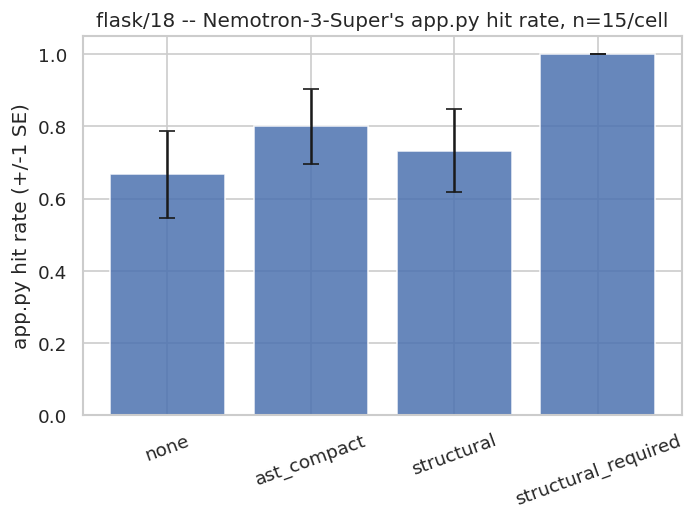

none (10/15) vs ast_compact (12/15): Fisher p=0.6817
none (10/15) vs structural (11/15): Fisher p=1.0000
none (10/15) vs structural_required (15/15): Fisher p=0.0421


In [9]:
def build_target_file_hit_df(repo, issue_idx, models, conditions, target_file):
    rows = []
    for path, d in load_trials(repo, issue_idx):
        model_short = short_model(d.get('model', ''))
        cond = d.get('map_type')
        if model_short not in models or cond not in conditions:
            continue
        pred = set(d.get('final_files_predicted_scorable') or [])
        rows.append({'model': model_short, 'condition': cond, 'rep': d.get('rep'), 'hit': target_file in pred})
    df = pd.DataFrame(rows)
    df['condition'] = pd.Categorical(df['condition'], categories=conditions, ordered=True)
    return df

df_f18_hit = build_target_file_hit_df(
    'flask', 18, ['Nemotron-3-Super'],
    ['none', 'ast_compact', 'structural', 'structural_required'],
    target_file='src/flask/app.py',
)
hit_table = df_f18_hit.groupby('condition', observed=True)['hit'].agg(['sum', 'count'])
hit_table['rate'] = (hit_table['sum'] / hit_table['count']).round(3)
display(hit_table)

fig, ax = plt.subplots(figsize=(6, 4.5))
rates = hit_table['rate']
sd = np.sqrt(rates * (1 - rates) / hit_table['count'])  # binomial SE as the spread indicator for a proportion
ax.bar(rates.index.astype(str), rates.values, yerr=sd.values, capsize=5, alpha=0.85, color=sns.color_palette()[0])
ax.set_ylabel('app.py hit rate (+/-1 SE)')
ax.set_title("flask/18 -- Nemotron-3-Super's app.py hit rate, n=15/cell")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

base = df_f18_hit[df_f18_hit.condition == 'none']['hit']
for cond in ['ast_compact', 'structural', 'structural_required']:
    other = df_f18_hit[df_f18_hit.condition == cond]['hit']
    table = [[base.sum(), len(base) - base.sum()], [other.sum(), len(other) - other.sum()]]
    _, p = stats.fisher_exact(table)
    print(f'none ({base.sum()}/{len(base)}) vs {cond} ({other.sum()}/{len(other)}): Fisher p={p:.4f}')

**Result at n=15**: the original 0% -> 100% swing does **not** replicate.
`app.py` hit rate is `none` **10/15 (67%)**, `ast_compact` 12/15 (80%,
p=0.68), `structural` 11/15 (73%, p=1.0), `structural_required` **15/15
(100%, p=0.042)**. Baseline alone at n=15 is already two-thirds correct
-- nowhere near the 0/3 that made this look like a clean causal
demonstration. Only the gated condition (`structural_required`) reaches
significance, and even that's a borderline p=0.042 that could plausibly
be explained by the already-documented, map-content-agnostic
submit-gate-forces-commitment effect (#18, #23) rather than this
specific traced mechanism.

**This meaningfully revises one of this project's flagship positive
findings.** The underlying mechanism -- `lookup_structure` genuinely
returning the exact line, and Nemotron genuinely reading it next in the
trials where that happens -- was directly observed and isn't in
question. What doesn't hold up is the *causal claim built on it*: that
this mechanism reliably converts a near-certain miss into a near-certain
hit. At n=15, the two delivery mechanisms the causal story was actually
about (`ast_compact` as passive context, `structural` as a voluntary
tool) show no significant lift over an already-fairly-strong baseline.
Recommend downgrading entry #46 from "directly-traced causal case" to
"directly-traced *mechanism*, not confirmed as *outcome-determining* at
higher n" in the next taxonomy pass.

## 7. `localstack/2` -- does DeepSeek's per-condition turn-exhaustion pattern hold at n=15?

**Recorded conjecture** (`model_failure_points.md` #49, DEVLOG launched
2026-08-09): DeepSeek's weak aggregate score here is turn-exhaustion, but
broken down by mechanism at n=3: `tool_free` hit `max_turns` **12/12
(100%)** -- worse than baseline -- while `context` was DeepSeek's *best*
mechanism. Within Study 1's three context conditions specifically:
`ast_compact` avoided `max_turns` entirely (content-explained -- the map
literally names the fix function), `cochange` complied/recovered cleanly
despite hitting `max_turns` just as often as other conditions (**not**
content-explained -- its co-change partners have no thematic link to the
bug), `freq` got neither benefit. Explicitly logged as *not resolving
into one clean story* -- the reason all 12 conditions were replicated
here, not a 4-condition subset.

This conjecture is fundamentally about a **rate** (how often a trial hits
`max_turns` at all), not just mean F1 -- so both are reported.

Scope: **all 12 conditions**, DeepSeek-V4-Flash only.

f1_mean  f1_sd  num_turns_mean  \
model             condition                                                     
DeepSeek-V4-Flash none                           0.822  0.278          24.867   
                  ast_compact                    0.756  0.266          22.467   
                  freq                           0.778  0.349          25.200   
                  cochange                       0.933  0.138          22.867   
                  structural                     0.889  0.272          23.933   
                  temporal_frequency             0.867  0.352          24.467   
                  temporal_cochange              0.644  0.367          26.133   
                  all_tools                      0.800  0.352          26.467   
                  structural_required            0.889  0.272          25.600   
                  temporal_frequency_required    0.844  0.278          23.400   
                  temporal_cochange_required     0.756  0.344          25.667   
                  all_tools_required             0.800  0.352          24.933   

                                               num_turns_sd  \
model             condition                                   
DeepSeek-V4-Flash none                                4.103   
                  ast_compact                         5.343   
                  freq                                4.663   
                  cochange                            6.643   
                  structural                          6.798   
                  temporal_frequency                  5.914   
                  temporal_cochange                   3.907   
                  all_tools                           4.422   
                  structural_required                 4.222   
                  temporal_frequency_required         6.345   
                  temporal_cochange_required          4.880   
                  all_tools_required                  4.803   

                                               input_tokens_mean  \
model             condition                                        
DeepSeek-V4-Flash none                                521619.267   
                  ast_compact                        1438725.600   
                  freq                                635493.733   
                  cochange                            746404.000   
                  structural                          536099.000   
                  temporal_frequency                  499319.667   
                  temporal_cochange                   614781.800   
                  all_tools                           713226.333   
                  structural_required                 635066.933   
                  temporal_frequency_required         536318.400   
                  temporal_cochange_required          648053.667   
                  all_tools_required                  569759.400   

                                               input_tokens_sd  \
model             condition                                      
DeepSeek-V4-Flash none                              165431.551   
                  ast_compact                       427409.106   
                  freq                              172913.752   
                  cochange                          320823.781   
                  structural                        231698.452   
                  temporal_frequency                189330.166   
                  temporal_cochange                 147368.145   
                  all_tools                         242851.334   
                  structural_required               171010.302   
                  temporal_frequency_required       222839.760   
                  temporal_cochange_required        209308.365   
                  all_tools_required                173114.098   

                                               output_tokens_mean  \
model             condition                                         
DeepSeek-V4-F

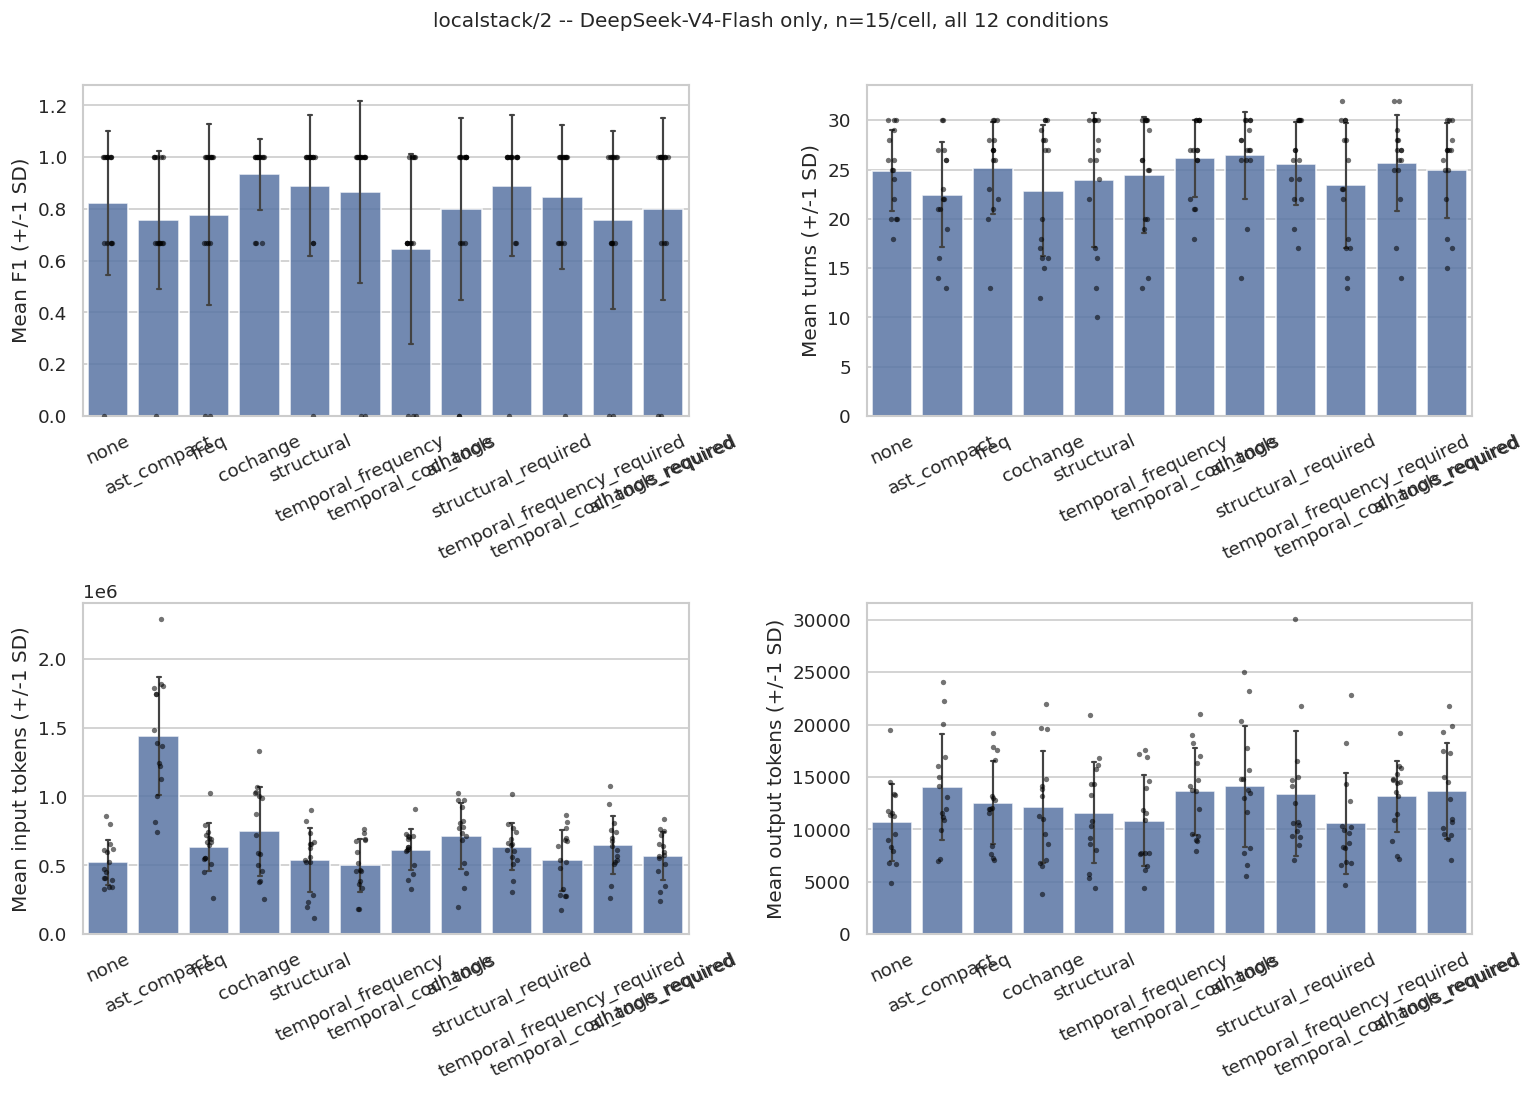

In [10]:
df_ls2 = build_df('localstack', 2, ['DeepSeek-V4-Flash'], ALL12)
display(summary_table(df_ls2))
plot_grid(df_ls2, 'localstack/2 -- DeepSeek-V4-Flash only, n=15/cell, all 12 conditions', hue=None)

In [11]:
def mechanism_of(cond):
    study1 = {'none', 'ast_compact', 'freq', 'cochange'}
    study2 = {'structural', 'temporal_frequency', 'temporal_cochange', 'all_tools'}
    if cond == 'none':
        return 'baseline'
    if cond in study1:
        return 'context'
    if cond in study2:
        return 'tool_free'
    return 'tool_required'

mt_by_cond = df_ls2.groupby('condition', observed=True)['stop_reason'].apply(lambda s: (s == 'max_turns').mean())
print('max_turns rate by exact condition (n=15 each):')
display(mt_by_cond.sort_values().rename('max_turns_rate').to_frame())

df_ls2 = df_ls2.assign(mechanism=df_ls2['condition'].map(mechanism_of))
mt_by_mech = df_ls2.groupby('mechanism', observed=True)['stop_reason'].apply(lambda s: (s == 'max_turns').mean())
print()
print('max_turns rate pooled by delivery mechanism:')
display(mt_by_mech.reindex(['baseline', 'context', 'tool_free', 'tool_required']).rename('max_turns_rate').to_frame())

max_turns rate by exact condition (n=15 each):


,max_turns_rate
condition,
ast_compact,0.066667
cochange,0.133333
temporal_cochange_required,0.133333
none,0.200000
all_tools,0.200000
freq,0.200000
all_tools_required,0.200000
temporal_frequency_required,0.266667
structural_required,0.266667



max_turns rate pooled by delivery mechanism:


,max_turns_rate
mechanism,
baseline,0.200000
context,0.133333
tool_free,0.300000
tool_required,0.216667


**Result at n=15**: the *direction* of the mechanism-level story survives
in a much more moderate form than the n=3 numbers suggested. Pooled by
delivery mechanism, `max_turns` rate is context **13.3%** < baseline
**20.0%** < tool_required **21.7%** < tool_free **30.0%** -- context is
genuinely the least turn-exhausted mechanism and tool_free the most, the
same ordering as the original finding, but nowhere near as extreme:
`tool_free`'s 100% (12/12) at n=3 is **30% (18/60 pooled)** at n=15, and
baseline's 67% (2/3) is **20% (3/15)** -- both original headline
percentages were driven by very small samples landing on the tail of a
real but much gentler distribution.

At the individual-condition level, `ast_compact` does have the lowest
`max_turns` rate of all 12 conditions (6.7%, 1/15) -- consistent with
"avoids max_turns because the map names the fix function directly" --
and `cochange` sits low too (13.3%, 2/15), consistent with "recovers
despite no content link." `freq` (20.0%) tracks baseline almost exactly,
consistent with "gets neither benefit." So the qualitative ranking from
the original entry (`ast_compact` best, `cochange` also good, `freq`
neutral) **does replicate directionally** -- none of the pairwise F1
differences from baseline reach significance (all p > 0.12), which is
expected given `max_turns` compliance (entry #50), not F1 mean shift, is
the actual mechanism in play here; a rate-based test on the underlying
binary (hit `max_turns` or not) is the more appropriate lens for this
issue's claim than the F1 bar charts, which stay fairly flat throughout.

**Overall status**: partially confirmed -- the qualitative
condition-level ordering holds up, the *magnitude* originally reported
(100% vs 0%) does not, and the open question flagged at replication-
launch time (why `cochange` recovers despite no content link) remains
genuinely open; n=15 didn't resolve it, just confirmed the effect it's
attached to is real but smaller than it first looked.

## Cross-cutting takeaway

Of the seven conjectures tested here, at n=15:

| Issue | Original claim | n=15 verdict |
|---|---|---|
| `keras/5` | F1 uplift is n=3 noise, not real | **Partially wrong** -- real for 2/4 models, reversed for a 3rd |
| `localstack/19` | Maps flip doc-file -> source-file answers | **Confirmed, model-gated** (2/4 models) |
| `gpt-engineer/9` | Every condition hurts (11/11) | **Direction holds (10/11), certainty overstated** (1/11 significant) |
| `scikit-learn/45` | Ministral+`freq` active harm | **Confirmed**, severity revised (0%->53%, not 0%->0%) |
| `requests/12` | Content-mediated co-change gradient | **Not supported** -- gradient dissolves entirely |
| `flask/18` | Directly-traced causal chain determines outcome | **Mechanism real, outcome-claim not supported** |
| `localstack/2` | Sharp per-mechanism turn-exhaustion split | **Direction holds, magnitude sharply revised down** |

The single most common failure mode of the *original* n=3 findings isn't
"wrong direction" -- it's **overstated magnitude and overstated
certainty**, especially anywhere a finding was originally reported as a
clean 0%/100% split (`flask/18`, `localstack/2`'s `tool_free` rate,
`keras/5`'s implicit framing). Every case that used a full 0% or 100%
baseline at n=3 turned out to sit at 20-70% once independent reps were
added. This is itself a useful, generalizable methodological finding for
the thesis: **treat any n=3 result reported as a deterministic split
(0/3 or 3/3) as the least trustworthy class of finding in this dataset**,
independent of how compelling the underlying causal story sounds.